In [2]:
import pandas as pd
import seaborn.objects as so
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import rcParams
import numpy as np

plt.style.use("cppp.notebook")

theme = {**sns.axes_style("ticks"), **rcParams}
so.Plot.config.theme.update(theme)

from cppp.load import load_multisensory_data


## Load data

In [3]:



df = load_multisensory_data(base_path="../data")

df["tracking_error"] = df["lefty_pos"] - df["righty_pos"]

df["offset_sign"] = df.groupby("participant")["cursor_offset"].transform(lambda x: np.sign(x.mean()))

df["tracking_error"] *= df["offset_sign"]

participants = df["participant"].unique()

participants_to_exclude = []
participants = [p for p in participants if p not in participants_to_exclude]

Multisensory DataFrame loaded from ../data/multisensory/df_all_phases_all_participants.csv with shape: (492343, 14)


## Load simulated CCGs

In [4]:
ccgs = pd.concat([pd.read_csv(f"../results/ppc/multisensory-simulations-ppc-{p}_1_2_7453_1000_2500_4_MultisensoryDelayModelPointMassDynamics.csv") for p in participants]).reset_index(drop=True)

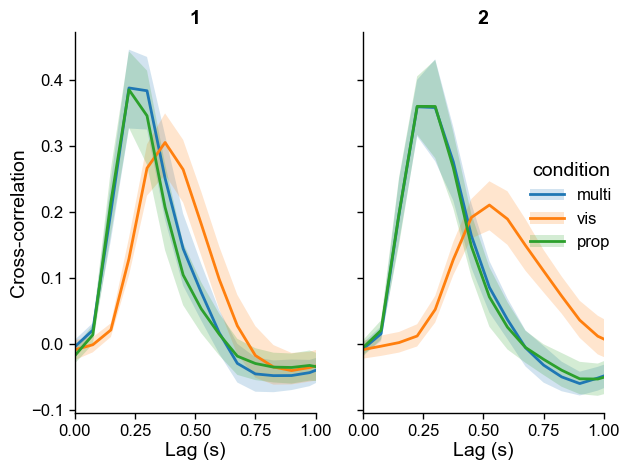

In [6]:
g = (so.Plot(ccgs[ccgs["model"] == "data"], x="lag", y="correlation", color="condition")
    .add(so.Line(), so.Agg())
    .add(so.Band(), so.Est())
    .facet(col="vis_noise", 
    # row="model", order={"row": ["data", "optimal", "no_integration", "equal_integration"]}
           )
    .label(x="Lag (s)", y="Cross-correlation")
    .limit(x=(-0.0, 1.0))
)
g.show()

In [7]:
ccg_params = ccgs.groupby(["participant", "model", "condition", "vis_noise"]).apply(
    lambda g: pd.Series({
        'peak': g['correlation'].max(),
        'lag': g.loc[g['correlation'].idxmax(), 'lag']
    }),
    include_groups=False
).reset_index()

In [8]:
ccgs.columns

Index(['participant', 'model', 'condition', 'vis_noise', 'lag', 'correlation'], dtype='object')

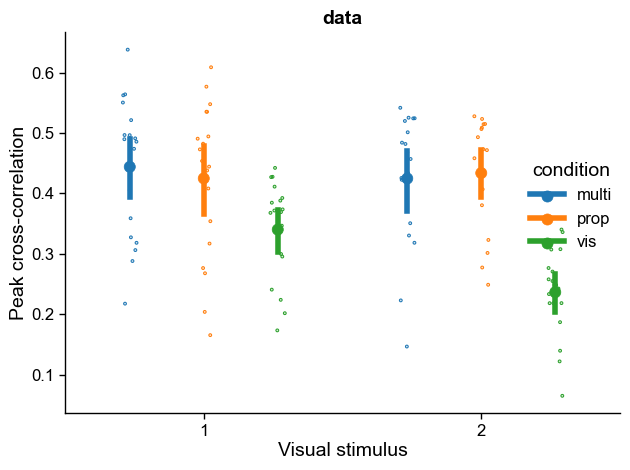

In [34]:
# [ccg_params["model"] == "data"]

g = (so.Plot(ccg_params[ccg_params["model"].isin(["data"])], x="vis_noise", y="peak", color="condition")
    .add(so.Dot(pointsize=8), so.Agg(), so.Dodge())
    .add(so.Dots(pointsize=2), so.Dodge(), so.Jitter())
    .add(so.Range(linewidth=4), so.Est(errorbar="ci"), so.Dodge())
    .facet(col="model")
    .scale(x=so.Nominal())
    .label(x="Visual stimulus", y="Peak cross-correlation")
    # .share(y=False)
)

g.show()

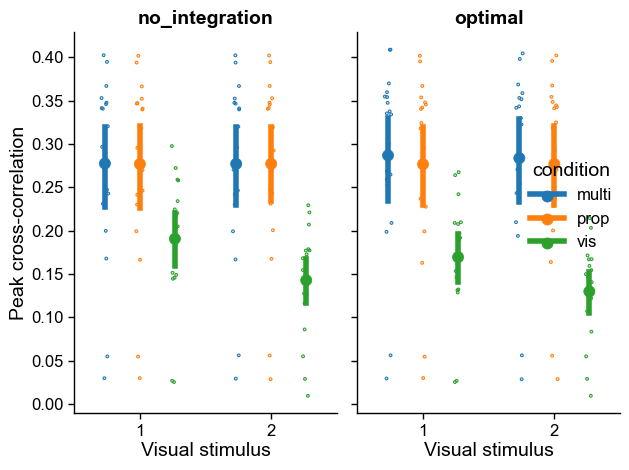

In [35]:
g = (so.Plot(ccg_params[ccg_params["model"].isin(["optimal", "no_integration"])], x="vis_noise", y="peak", color="condition")
    .add(so.Dot(pointsize=8), so.Agg(), so.Dodge())
    .add(so.Dots(pointsize=2), so.Dodge(), so.Jitter())
    .add(so.Range(linewidth=4), so.Est(errorbar="ci"), so.Dodge())
    .facet(col="model")
    .scale(x=so.Nominal())
    .label(x="Visual stimulus", y="Peak cross-correlation")
    # .share(y=False)
)

g.show()

In [29]:
df_sim = pd.concat([pd.read_csv(f"../results/calibration/multisensory-simulations-calibration-{p}_1_2_7453_1000_2500_4_MultisensoryDelayModelPointMassDynamics.csv") for p in participants]).reset_index(drop=True)

df_sim["tracking_error"] = df_sim["lefty_pos"] - (df_sim["righty_pos"])

df_sim["offset_sign"] = df_sim.groupby("participant")["cursor_offset"].transform(
    lambda x: np.sign(x.mean())
)

df_sim["tracking_error"] *= df_sim["offset_sign"]



In [30]:
# replace 'value' with your measurement column name
pre_means = (
    df[df['phase'] == 'pre_cal']
    .groupby(['participant', 'type', 'vis_noise'])['tracking_error']
    .mean()
    .reset_index(name='pre_mean')
)

df = df.merge(pre_means, on=['participant', 'type', 'vis_noise'], how='left')
df['tracking_error'] = df['tracking_error'] - df['pre_mean']
# optional: handle groups with no pre_cal by filling
# df['tracking_error_centered'] = df['value'] - df['pre_mean'].fillna(0)

# add data to simulation dataframe
df["model"] = "data"

df_sim = pd.concat([df, df_sim]).reset_index(drop=True)

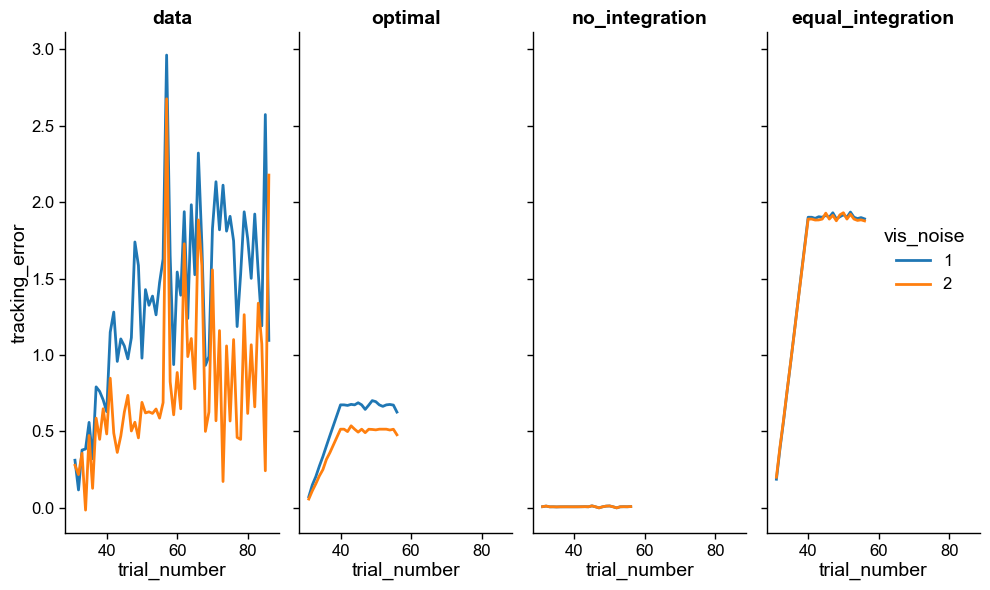

In [31]:

g = (
    so.Plot(
        df_sim[(df_sim["phase"].isin(["calibration", "post_cal"]))],
        x="trial_number",
        y="tracking_error",
        color="vis_noise",
    )
    .add(so.Line(), so.Agg())
    # .add(so.Band(), so.Est())
    # .add(so.Line(alpha=0.5), so.Agg(), group="participant")
    # .add(so.Band(), so.Est())
    .scale(color=so.Nominal())
    .facet(col="model")
    .layout(size=(10, 6))
)
g.show()